# Importing Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import pickle, gzip
from sklearn import svm
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, confusion_matrix, PrecisionRecallDisplay, accuracy_score, matthews_corrcoef, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import math
from google.colab import files
uploaded = files.upload()
!apt-get install -y fonts-liberation

Saving benchmarking.tsv to benchmarking.tsv
Saving performance.tsv to performance.tsv
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-liberation is already the newest version (1:1.07.4-11).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.


# Functions

## Feature Extraction

In [2]:
def sequence_composition(sequence:str) -> np.ndarray[np.float64]:
  sequence = sequence[:40]
  alphabet = "AQLSREKTNGMWDHFYCIPV"
  composition_matrix = np.zeros((20,40))
  composition_vector = np.zeros((20))
  for i in range(len(alphabet)):
    for j in range(len(sequence)):
      if alphabet[i] == sequence[j]:
        composition_matrix[i][j] += 1
        composition_vector[i] += composition_matrix[i][j]
  composition_vector = composition_vector/40
  return composition_vector

def hp_ai(sequence:str, window_size:int = 6 ) -> np.ndarray[np.float64]:
  kd_scale = {
    'R': -4.5,  # Arg
    'K': -3.9,  # Lys
    'N': -3.5,  # Asn
    'D': -3.5,  # Asp
    'Q': -3.5,  # Gln
    'E': -3.5,  # Glu
    'H': -3.2,  # His
    'P': -1.6,  # Pro
    'Y': -1.3,  # Tyr
    'W': -0.9,  # Trp
    'S': -0.8,  # Ser
    'T': -0.7,  # Thr
    'G': -0.4,  # Gly
    'A':  1.8,  # Ala
    'M':  1.9,  # Met
    'C':  2.5,  # Cys
    'F':  2.8,  # Phe
    'L':  3.8,  # Leu
    'V':  4.2,  # Val
    'I':  4.5   # Ile
    }

  a = 2.9 # relative volume of valine
  b = 3.9 # relative volume leucine/isoleucine

  sequence = sequence[:40]
  # padding to have as many scores as residues  (each window refers to the central res)
  d = int(window_size/2)
  sequence = "X"*d + sequence + "X"*d #padding
  hydrophobicities = np.array([])
  AIs = np.array([])  #aliphatic indexes
  for i in range(len(sequence)-(window_size)+1):
      counts_A = 0
      counts_V = 0
      counts_I = 0
      counts_L = 0
      hydrophobicity_score = 0
      window = sequence[i:i+window_size]
      for j in range(window_size):
        if window[j] != "X":
          hydrophobicity_score = (hydrophobicity_score + kd_scale[window[j]])
          if window[j] == 'A':
              counts_A += 1
          elif window[j] == 'V':
              counts_V += 1
          elif window[j] == 'I':
              counts_I += 1
          elif window[j] == 'L':
                counts_L += 1
      X_A = (counts_A / window_size)
      X_V = (counts_V / window_size)
      X_I = (counts_I / window_size)
      X_L = (counts_L / window_size)
      AI = X_A + a * X_V + b * (X_I + X_L) #Aliphatic Index Formula
      hydrophobicities = np.append(hydrophobicities, hydrophobicity_score / window_size)
      AIs = np.append(AIs, AI)
  H_AI = np.array([hydrophobicities.mean(), hydrophobicities.max(), np.argmax(hydrophobicities), AIs.mean(), AIs.max(), np.argmax(AIs)])
  return H_AI  #hydrophobicity and aliphatic index alltogether

def SSE(sequence,window_size):
  alpha_helix_scale = {
      "G": 0.570,  # Gly
      "P": 0.570,  # Pro
      "Y": 0.690,  # Tyr
      "C": 0.700,  # Cys
      "S": 0.770,  # Ser
      "T": 0.830,  # Thr
      "N": 0.670,  # Asn
      "R": 0.980,  # Arg
      "H": 1.000,  # His
      "D": 1.010,  # Asp
      "I": 1.080,  # Ile
      "W": 1.080,  # Trp
      "Q": 1.110,  # Gln
      "F": 1.130,  # Phe
      "K": 1.160,  # Lys
      "V": 1.060,  # Val
      "L": 1.210,  # Leu
      "A": 1.420,  # Ala
      "M": 1.450,  # Met
      "E": 1.510   # Glu
  }
  beta_sheet_scale = {
      "E": 0.370,  # Glu
      "D": 0.540,  # Asp
      "P": 0.550,  # Pro
      "G": 0.750,  # Gly
      "S": 0.750,  # Ser
      "K": 0.740,  # Lys
      "H": 0.870,  # His
      "N": 0.890,  # Asn
      "R": 0.930,  # Arg
      "A": 0.830,  # Ala
      "M": 1.050,  # Met
      "Q": 1.100,  # Gln
      "C": 1.190,  # Cys
      "T": 1.190,  # Thr
      "L": 1.300,  # Leu
      "F": 1.380,  # Phe
      "W": 1.370,  # Trp
      "Y": 1.470,  # Tyr
      "I": 1.600,  # Ile
      "V": 1.700   # Val
  }
  sequence = sequence[:40]
  # padding to have as many scores as residues (each window refers to the central res)
  d = int(window_size/2)
  sequence = "X"*d + sequence + "X"*d #padding
  alpha_helix = np.array([])
  beta_sheet = np.array([])
  for i in range(len(sequence)-(window_size)+1):
      alpha_score = 0
      beta_score = 0
      window = sequence[i:i+window_size]
      for j in range(window_size):
        w = 1 - abs(j - (window_size - 1)/2) / ((window_size - 1)/2)
        if window[j] != "X":
          alpha_score = alpha_score + w * alpha_helix_scale[window[j]]
          beta_score = beta_score + w * beta_sheet_scale[window[j]]
      alpha_helix = np.append(alpha_helix, alpha_score / window_size)
      beta_sheet = np.append(beta_sheet, beta_score / window_size)
  alpha_feature = np.array([alpha_helix.mean(), alpha_helix.max(), np.argmax(alpha_helix)])
  beta_feature = np.array([beta_sheet.mean(), beta_sheet.max(), np.argmax(beta_sheet)])
  return alpha_helix, alpha_feature, beta_sheet, beta_feature

def charge_seq(sequence, window_size):
  res_charges = {
        'K': 1,   # Lys
        'R': 1,   # Arg
        'H': 0.5, # His (partial positive)
        'D': -1,  # Asp
        'E': -1   # Glu
    }

  sequence = sequence[:20]
  # padding to have as many scores as residues  (each window refers to the central res)
  d = int(window_size/2)
  sequence = "X"*d + sequence + "X"*d #padding

  norm_charges = np.array([])

  for i in range(len(sequence)-(window_size)+1):
      charge = 0
      window = sequence[i:i+window_size]
      for j in range(window_size):
        if window[j] != "X" and window[j] in res_charges:
          charge = (charge + res_charges[window[j]])
      norm_charges = np.append(norm_charges, charge / window_size)
  charge_feature = np.array([norm_charges.max(), np.argmax(norm_charges), norm_charges.min(), np.argmin(norm_charges)])
  return norm_charges, charge_feature


def tm_helix_propensity(sequence: str, window_size: int = 7) -> np.ndarray[np.float64]:
    #TM Helix Propensity Scale (ProParam)
    tm_helix_propensity_scale = {
        'F':  1.980,
        'I':  1.970,
        'L':  1.820,
        'W':  1.530,
        'V':  1.460,
        'M':  1.400,
        'Y':  0.490,
        'A':  0.380,
        'G': -0.190,
        'C': -0.300,
        'T': -0.320,
        'S': -0.530,
        'H': -1.440,
        'P': -1.440,
        'N': -1.620,
        'Q': -1.840,
        'R': -2.570,
        'E': -2.900,
        'D': -3.270,
        'K': -3.460
    }

    sequence = sequence[:80]

    d = int(window_size / 2)     #Padding
    sequence = "X" * d + sequence + "X" * d

    tm_scores = np.array([])

    for i in range(len(sequence) - window_size + 1):
        score = 0.0
        window = sequence[i:i + window_size]

        for j in range(window_size):   #Weighted average
            w = 1 - abs(j - (window_size - 1) / 2) / ((window_size - 1) / 2)
            if window[j] in tm_helix_propensity_scale:
                score += w * tm_helix_propensity_scale[window[j]]
        tm_scores = np.append(tm_scores, score / window_size)

    tm_feature = np.array([
        tm_scores.mean(),        #mean score across sequence
        tm_scores.max(),         #max score
        np.argmax(tm_scores)     #position of max
    ])

    return tm_scores, tm_feature

def extract_features(seqs):
  features = np.empty([len(seqs), 39])

  for row, seq in enumerate(seqs):
    feature = np.array(())
    aa_comp = sequence_composition(seq)
    hyd_ali_index = hp_ai(seq)
    _, alpha, _, beta = SSE(seq, window_size=9)
    _, charges = charge_seq(seq, window_size=3)
    _, tm_propensity = tm_helix_propensity(seq, window_size=7)

    feature = np.concatenate((aa_comp, hyd_ali_index, tm_propensity, alpha, beta, charges), axis = None)

    features[row] = feature
# Return individual feature vectors
  return features

## SVM and Random Forest for Feature Selection

In [3]:
# FEATURE SCALING
def feature_scaler(features):
  scaler = StandardScaler()
  scaled_feature = scaler.fit_transform(features)
  return scaled_feature

# Baseline SVM (all features) — manual grid over C and gamma on validation

def svm_pipeline(C, gamma, kernel):
    return Pipeline([
        ("svm", SVC(kernel=kernel, C=C, gamma=gamma, random_state=42))
    ])

def grid_search(kernels, C_grid, gamma_grid, X_train, Y_train, X_toeval, Y_toeval):
  best_mcc = -1
  best_par = None
  for kernel in kernels:
    for C in C_grid:
        for gamma in gamma_grid:
            model = svm_pipeline(C, gamma, kernel)
            model = model.fit(X_train, Y_train)                 # fit on TRAIN
            pred_val = model.predict(X_toeval)
            val_mcc = matthews_corrcoef(Y_toeval, pred_val)   # evaluate on VALIDATION
            if val_mcc > best_mcc:
                best_mcc = val_mcc
                best_par = {"C": C, "gamma": gamma, "kernel": kernel}
  return best_mcc, best_par

def mcc_subset(C, gamma, kernel, subset_features):
    # subset by feature names
    idx = [np.where(feature_names == f)[0][0] for f in subset_features]
    Xtr = X_train[:, idx]
    Xva = X_val[:, idx]
    model = svm_pipeline(C, gamma, kernel)
    model = model.fit(Xtr, Y_train)     # train on TRAIN only
    pred = model.predict(Xva)     # predict on VAL only

    return matthews_corrcoef(Y_val, pred)  # MCC on VALIDATION


## Plots

In [4]:
def plot_confusion_matrix_custom(y_true, y_pred, features):
    cm_ = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm_.ravel()
    plot_cm = np.array([[TP, FP],
                        [FN, TN]])

    cell_colors = np.array([['#fde725ff', '#483677ff'],
                            ['#2d708eff', '#3cbb75ff']])

    fig, ax = plt.subplots(figsize=(5, 4))
    for r in range(2):
        for c in range(2):
            ax.add_patch(plt.Rectangle((c, 1-r), 1, 1, color=cell_colors[r, c],
                                       edgecolor=None, linewidth=0))
            text_color = 'black' if (r, c) == (0, 0) else 'white'
            ax.text(c + 0.5, 1.5 - r, plot_cm[r, c],
                    ha='center', va='center', fontsize=12,
                    fontfamily='Liberation Serif', color=text_color)

    ax.set_xlim(0, 2)
    ax.set_ylim(0, 2)
    ax.set_xticks([0.5, 1.5])
    ax.set_xticklabels(['True Positive', 'True Negative'], fontname='Liberation Serif')
    ax.xaxis.set_label_position('top')
    ax.xaxis.tick_top()
    ax.tick_params(axis='x', which='both', length=0)
    ax.set_yticks([0.5, 1.5])
    ax.set_yticklabels(['Predicted Negative', 'Predicted Positive'],
                       rotation=90, va='center', fontname='Liberation Serif')

    ax.set_title(f'Confusion Matrix ({features} - Performance Run)',
                 fontsize=14, fontfamily='Liberation Serif', pad=10)
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.tight_layout()


def plot_combined_confusion_matrix(cm_list, n_rounds):
    sum_cm = np.sum(cm_list, axis=0)
    TN, FP, FN, TP = sum_cm.ravel()
    plot_cm = np.array([[TP, FP],
                        [FN, TN]])

    cell_colors = np.array([['#fde725ff', '#483677ff'],
                            ['#2d708eff', '#3cbb75ff']])

    fig, ax = plt.subplots(figsize=(5, 4))
    for r in range(2):
        for c in range(2):
            ax.add_patch(plt.Rectangle((c, 1-r), 1, 1, color=cell_colors[r, c],
                                       edgecolor=None, linewidth=0))
            text_color = 'black' if (r, c) == (0, 0) else 'white'
            ax.text(c + 0.5, 1.5 - r, plot_cm[r, c],
                    ha='center', va='center', fontsize=12,
                    fontfamily='Liberation Serif', color=text_color)

    ax.set_xlim(0, 2)
    ax.set_ylim(0, 2)
    ax.set_xticks([0.5, 1.5])
    ax.set_xticklabels(['True Positive', 'True Negative'], fontname='Liberation Serif')
    ax.xaxis.set_label_position('top')
    ax.xaxis.tick_top()
    ax.tick_params(axis='x', which='both', length=0)
    ax.set_yticks([0.5, 1.5])
    ax.set_yticklabels(['Predicted Negative', 'Predicted Positive'],
                       rotation=90, va='center', fontname='Liberation Serif')

    ax.set_title(f'Combined Confusion Matrix ({n_rounds} Rounds)',
                 fontsize=14, fontfamily='Liberation Serif', pad=10)
    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()

# Performance

Baseline SVM (over all 39 features) — best validation MCC for Performance Run: 0.865
 with hyperparameters {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}



<Figure size 640x480 with 0 Axes>

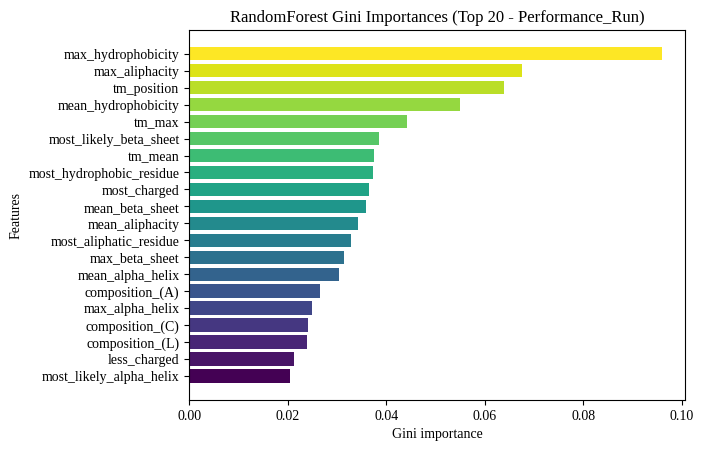


Best 27 features on validation (using baseline SVM hyperparameters): k=29, val_mcc=0.845



<Figure size 640x480 with 0 Axes>

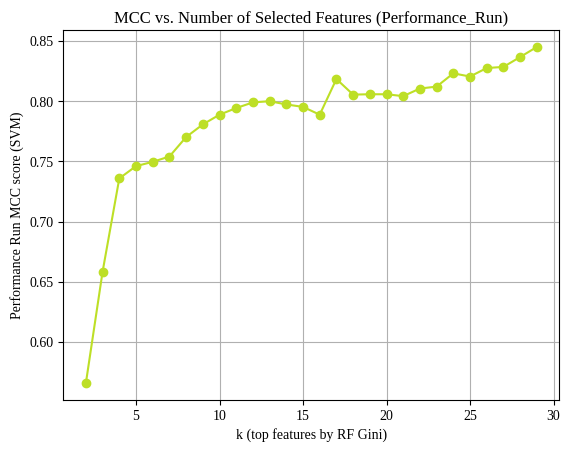

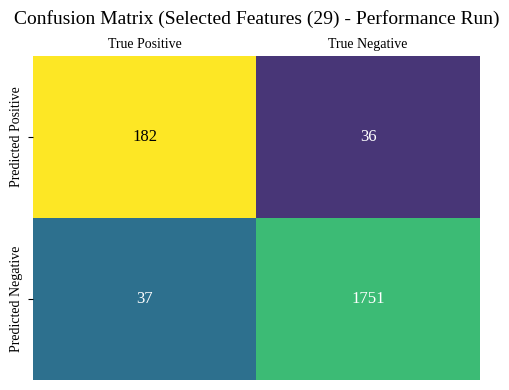

Selected features (29 over the best 29: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}

Best MCC score on selected features:  0.845
 with best hyperparameters: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}

Benchmarking MCC score (selected features, tuned on val):  0.813



<Figure size 500x400 with 0 Axes>

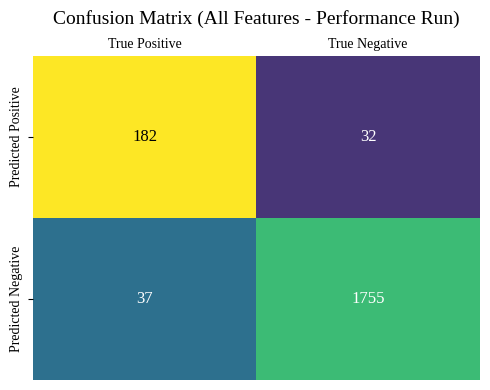

Test MCC score (over all features, baseline tuned on val):  0.821

Selected features Based Model Metrics:
MCC: 0.8125351639438458
Precision: 0.8348623853211009
Recall: 0.8310502283105022
Accuracy: 0.9636091724825523
F1 Score: 0.8329519450800915

All Features Based Model Metrics:
MCC: 0.8214392243124397
Precision: 0.8504672897196262
Recall: 0.8310502283105022
Accuracy: 0.9656031904287139
F1 Score: 0.8406466512702079







<Figure size 500x400 with 0 Axes>

In [11]:
df1 = pd.read_csv("performance.tsv", sep = "\t")
df2 = pd.read_csv("benchmarking.tsv", sep = "\t")

# Set the theme globally
mpl.rcParams['font.family'] = 'Liberation Serif'
mpl.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.viridis(np.linspace(0, 1, 10)))
train_df, val_df = (
    df1.query("Label != 5")[["Frag_90", "Class", "Label"]],
    df1.query("Label == 5")[["Frag_90", "Class", "Label"]]
)

bench_df = df2[["Frag_90", "Class", "Label"]]

feature_names = np.array([f"composition_({residue})" for residue in "AQLSREKTNGMWDHFYCIPV"] + # 20 aa composition
 ["mean_hydrophobicity", "max_hydrophobicity", "most_hydrophobic_residue",
  "mean_aliphacity", "max_aliphacity", "most_aliphatic_residue", # 6 hydrophobicity and aliphacity
  "tm_mean", "tm_max", "tm_position", # 3 tm propensity features
  "mean_alpha_helix", "max_alpha_helix", "most_likely_alpha_helix",
  "mean_beta_sheet", "max_beta_sheet", "most_likely_beta_sheet", # 6 accounting for SSE
  "max_charge", "most_charged", "min_charge", "less_charged" # 4 accounting for charge
  ])
# X == features
# Y == classes
cm_sel = []
cm_all = []
train_seqs = train_df["Frag_90"]
Y_train = train_df["Class"]

val_seqs = val_df["Frag_90"]
Y_val = val_df["Class"]

bench_seqs = bench_df["Frag_90"]
Y_bench = bench_df["Class"]



# FEATURE EXTRACTION AND SCALING
X_train = feature_scaler(extract_features(train_seqs))
X_val = feature_scaler(extract_features(val_seqs))
X_bench = feature_scaler(extract_features(bench_seqs))

kernels = ["linear", "rbf", "poly"]
C_grid = [0.1, 1, 10, 100]
gamma_grid = ["scale", 0.01, 0.1, 1.0]

# Grid on C and Gamma over the validation set

best_mcc , mcc_params = grid_search(kernels, C_grid, gamma_grid, X_train, Y_train, X_val, Y_val)

print(f"Baseline SVM (over all {len(X_train[0])} features) — best validation MCC for Performance Run: "
      f"{best_mcc:.3f}\n with hyperparameters {mcc_params}")
print("")

rf = RandomForestClassifier(      # <--ADDRESSING CLASS UNBALANCE
        n_estimators=400, random_state=42,
        n_jobs=-1, class_weight={0: 9, 1: 1}
)
rf.fit(X_train, Y_train)  # fit only on TRAIN
gini_imp = pd.Series(rf.feature_importances_, index = feature_names).sort_values(ascending=False)
gini_df = gini_imp.reset_index()
gini_df.columns = ["feature", "importance"]
gini_df.to_csv("Features_gini_Performance_Run.tsv", sep = "\t", index = False, header = True)

# Plot top 20
plt.figure()
colors = plt.cm.viridis(np.linspace(0, 1, 20))
plt.barh(gini_df["feature"].head(20)[::-1],gini_df["importance"].head(20)[::-1],color=colors)
plt.xlabel("Gini importance")
plt.ylabel("Features")
plt.title(f"RandomForest Gini Importances (Top 20 - Performance Run)")
plt.savefig(f"Top_Features_Performance_Run.pdf", dpi = 1000, format = "pdf", bbox_inches="tight", pad_inches = 0.2)
plt.clf()
plt.figure()
colors = plt.cm.viridis(np.linspace(0, 1, 20))
plt.barh(gini_df["feature"].head(20)[::-1],gini_df["importance"].head(20)[::-1],color=colors)
plt.xlabel("Gini importance")
plt.ylabel("Features")
plt.title(f"RandomForest Gini Importances (Top 20 - Performance_Run)")
plt.show()
print("")

ks = list(range(2, min(30, X_train.shape[1]+1)))  # keep it small for speed/clarity
mcc_curve = []

for k in ks:
    subset = gini_df["feature"].head(k).tolist()
    mcc_k = mcc_subset(mcc_params["C"], mcc_params["gamma"], mcc_params["kernel"], subset)
    mcc_curve.append(mcc_k)

mcc_idx = int(np.argmax(mcc_curve))
mcc_ks = ks[mcc_idx]
print(f"Best {mcc_idx} features on validation (using baseline SVM hyperparameters): k={mcc_ks}, val_mcc={mcc_curve[mcc_idx]:.3f}")
print("")

plt.figure()
plt.plot(ks, mcc_curve, marker="o", color=plt.cm.viridis(0.9))
plt.xlabel("k (top features by RF Gini)")
plt.ylabel("Performance Run MCC score (SVM)")
plt.title(f"MCC vs. Number of Selected Features (Performance_Run)")
plt.grid(True)
plt.savefig(f"MCC_Performance_Run.pdf", dpi = 1000, format = "pdf", bbox_inches="tight", pad_inches = 0.2)
plt.clf()
plt.figure()
plt.plot(ks, mcc_curve, marker="o", color=plt.cm.viridis(0.9))
plt.xlabel("k (top features by RF Gini)")
plt.ylabel("Performance Run MCC score (SVM)")
plt.title(f"MCC vs. Number of Selected Features (Performance_Run)")
plt.grid(True)
plt.show()
print("")

# Use the best k from the validation curve
feature_subset = gini_df["feature"].head(mcc_ks).tolist()

mcc_idx = [np.where(feature_names == f)[0][0] for f in feature_subset]

Xtr = X_train[:, mcc_idx]
Xva = X_val[:, mcc_idx]
Xbe = X_bench[:, mcc_idx]

# Manual grid search again but now restricted to the selected features
mcc_sel, mcc_selp = grid_search(kernels, C_grid, gamma_grid, Xtr, Y_train, Xva, Y_val)

# Train final model on TRAIN+VAL with best params (optional) or just TRAIN; here we keep TRAIN only as per your outline

final_model = svm_pipeline(mcc_selp["C"], mcc_selp["gamma"], mcc_selp["kernel"])
final_model = final_model.fit(Xtr, Y_train)

pickle.dump(final_model, gzip.open(f"SVM(selected)_mcc_Performance_Run.pkl.gz","w"))
predmcc_bench = final_model.predict(Xbe)
test_mcc = matthews_corrcoef(Y_bench, predmcc_bench)

cm_sel.append(confusion_matrix(Y_bench, predmcc_bench))

plot_confusion_matrix_custom(Y_bench, predmcc_bench, f"Selected Features ({len(mcc_idx)})")
plt.show()
plot_confusion_matrix_custom(Y_bench, predmcc_bench, f"Selected Features ({len(mcc_idx)})")
plt.savefig(f"CM_selected_Prediction_Run.pdf", dpi=1000, format="pdf", bbox_inches="tight", pad_inches=0.2)
plt.clf()

metrics_mcc_values = [test_mcc, precision_score(Y_bench, predmcc_bench), recall_score(Y_bench, predmcc_bench), accuracy_score(Y_bench, predmcc_bench), f1_score(Y_bench, predmcc_bench)]
pickle.dump(metrics_mcc_values, gzip.open(f"Metrics(sel)_mcc_Performance_Run.pkl.gz","w"))

print(f"Selected features ({len(mcc_idx)} over the best {len(ks)+1}:", mcc_selp)
print("")
print("Best MCC score on selected features: ", f"{mcc_sel:.3f}\n", "with best hyperparameters:", mcc_selp)
print("")
print("Benchmarking MCC score (selected features, tuned on val): ", f"{test_mcc:.3f}")
print("")

df2["Prediction"] = predmcc_bench
df2.to_csv("results_SVM.tsv", sep = "\t", index = False)

# For comparison: test MCC with all features using baseline best params

baseline_model = svm_pipeline(mcc_params["C"], mcc_params["gamma"], mcc_params["kernel"])
baseline_model.fit(X_train, Y_train)
pickle.dump(baseline_model, gzip.open(f"SVM(all)_mcc_Performance_Run.pkl.gz","w"))
baseline_predtest = baseline_model.predict(X_bench)
test_mcc_all = matthews_corrcoef(Y_bench, baseline_predtest)

cm_all.append(confusion_matrix(Y_bench, baseline_predtest))

plot_confusion_matrix_custom(Y_bench, baseline_predtest, "All Features")
plt.show()
plot_confusion_matrix_custom(Y_bench, baseline_predtest, "All Features")
plt.savefig(f"CM_all_Performance_run.pdf", dpi=1000, format="pdf", bbox_inches="tight", pad_inches=0.2)
plt.clf()

metrics_mcc_all_values = [test_mcc_all, precision_score(Y_bench, baseline_predtest), recall_score(Y_bench, baseline_predtest), accuracy_score(Y_bench, baseline_predtest), f1_score(Y_bench, baseline_predtest)]
pickle.dump(metrics_mcc_all_values, gzip.open(f"Metrics(all)_mcc_Performance_Run.pkl.gz","w"))

print("Test MCC score (over all features, baseline tuned on val): ", f"{test_mcc_all:.3f}")
print("")
print("Selected features Based Model Metrics:")
mets = ["MCC", "Precision", "Recall", "Accuracy", "F1 Score"]
for j in range(len(metrics_mcc_values)):
  print(mets[j]+": "+str(metrics_mcc_values[j]))
print("")
print("All Features Based Model Metrics:")
for j in range(len(metrics_mcc_all_values)):
  print(mets[j]+": "+str(metrics_mcc_all_values[j]))
print("")
print("")
print("")
print("")
print("")